In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

from sklearn.metrics import mean_squared_error
import numpy as np

In [ ]:
# !pip uninstall lightgbm

In [32]:
# 1) 데이터 불러오기
df = pd.read_csv("./korea_apartment_sample.csv")


# 2) X(입력), y(타깃) 분리
X = df.drop("거래금액_만원", axis=1)
y = df["거래금액_만원"]

In [33]:
X

,지역코드,거래연도,거래월,전용면적,층,건물연식,세대수,지하철거리_km,지역소득_백만원,학군점수
0,1,2020,5,129.193131,31,2,486,2.473376,6.098772,1.067025
1,4,2015,3,120.466961,15,3,830,2.563601,10.264941,3.716797
2,3,2023,3,49.906979,9,24,1606,2.407747,8.197957,1.306273
3,2,2015,1,37.073566,23,37,1476,3.177218,12.291632,2.683045
4,0,2019,12,132.847062,19,14,1126,0.453609,13.231019,3.406729
...,...,...,...,...,...,...,...,...,...,...
495,1,2022,9,70.239909,9,38,1833,1.933101,9.917669,2.406169
496,2,2021,7,93.377342,20,0,1320,3.312420,12.142603,3.441510
497,0,2022,7,44.931719,1,16,716,1.734813,12.378068,1.096441
498,4,2020,11,47.528196,8,40,595,1.953776,6.309089,1.465836


In [34]:
y

0      76628
1      89874
2      53557
3      46731
4      81917
       ...  
495    49232
496    72429
497    40979
498    50275
499    70459
Name: 거래금액_만원, Length: 500, dtype: int64

In [35]:
# 3) Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
# 4) 모델 학습 (랜덤포레스트)
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
model2 = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)
model2.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000088 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 775
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 10
[LightGBM] [Info] Start training from score 65260.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [38]:
# 5) 예측 및 성능 출력
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R²   : {r2:.4f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

R²   : 0.8697
MSE  : 37621995.52
RMSE : 6133.68


In [39]:
# 5) 예측 및 성능 출력
y_pred2 = model2.predict(X_test)
r22 = r2_score(y_test, y_pred2)

mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)

print(f"R²   : {r22:.4f}")
print(f"MSE  : {mse2:.2f}")
print(f"RMSE : {rmse2:.2f}")

R²   : 0.8961
MSE  : 29990883.93
RMSE : 5476.39


In [41]:
from sklearn.linear_model import LinearRegression

from sklearn.discriminant_analysis import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR


base_models = [
    ("lr", LinearRegression()),
    ("rf", RandomForestRegressor(
        n_estimators=300, random_state=42
    )),
    ("svr", make_pipeline(
        StandardScaler(),
        SVR(kernel="rbf", C=20, epsilon=0.1)
    )),
    ("lgbm", LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        random_state=42
    ))
]


In [42]:
final_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

In [43]:
from sklearn.ensemble import StackingRegressor


stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=final_model,
    passthrough=False,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000133 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 775
[LightGBM] [Info] Number of data points in the train set: 400, number of used features: 10
[LightGBM] [Info] Start training from score 65260.500000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

,estimators,"[('lr', ...), ('rf', ...), ...]"
,final_estimator,LGBMRegressor...ndom_state=42)
,cv,None
,n_jobs,-1
,passthrough,False
,verbose,0
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
y_pred3 = stack_model.predict(X_test)

mse3 = mean_squared_error(y_test, y_pred3)
rmse3 = np.sqrt(mse3)
r23 = r2_score(y_test, y_pred3)

print(f"=== Stacking(LR + RF + SVR + LGBM) 모델 ===")
print(f"R²   : {r23:.4f}")
print(f"MSE  : {mse3:.2f}")
print(f"RMSE : {rmse3:.2f}")

=== Stacking(LR + RF + SVR + LGBM) 모델 ===
R²   : 0.8911
MSE  : 31437388.85
RMSE : 5606.91


/Users/administrator/miniconda3/envs/multimodal_rag/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [45]:
import matplotlib.pyplot as plt

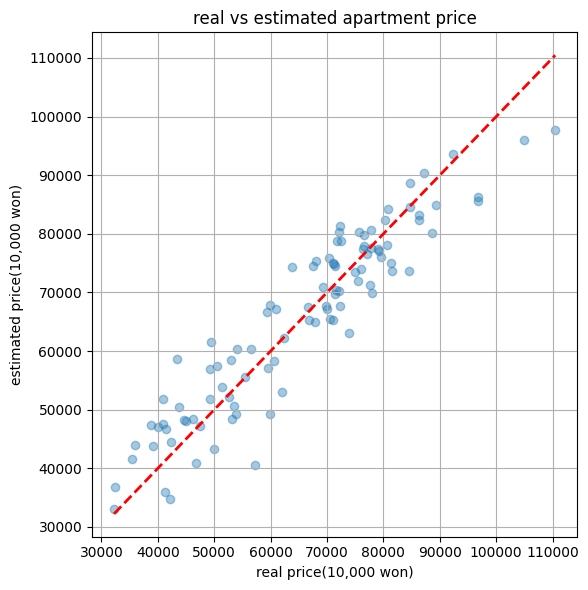

In [47]:
plt.figure(figsize=(6, 6))

# 산점도: x축 실제, y축 예측
plt.scatter(y_test, y_pred, alpha=0.4)

# y = x 기준선 (완벽 예측선)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.title("real vs estimated apartment price")
plt.grid(True)
plt.tight_layout()
plt.show()

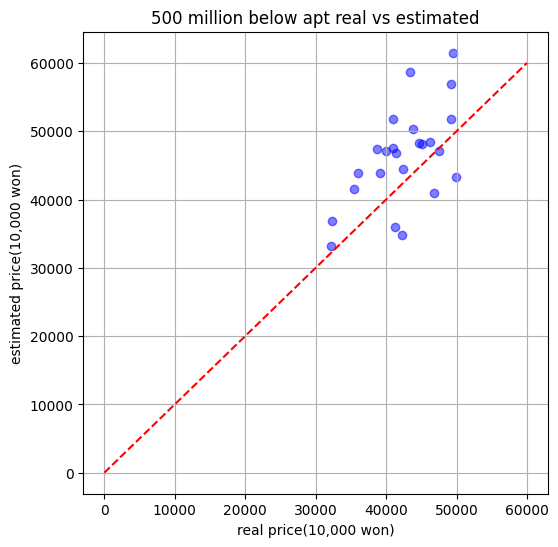

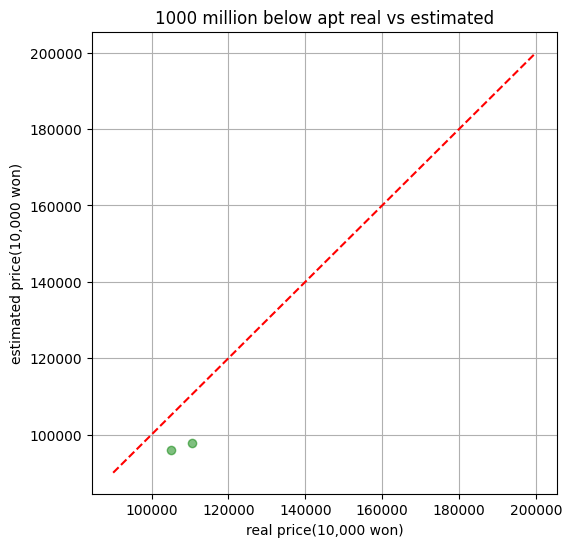

In [48]:
import matplotlib.pyplot as plt

# 5억 이하(<=50,000)
mask_low = y_test <= 50000

plt.figure(figsize=(6,6))
plt.scatter(y_test[mask_low], y_pred[mask_low], alpha=0.5, color='blue')
plt.plot([0, 60000], [0, 60000], 'r--')
plt.title("500 million below apt real vs estimated")
plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.grid(True)
plt.show()

# 10억 이상(>=100,000)
mask_high = y_test >= 100000

plt.figure(figsize=(6,6))
plt.scatter(y_test[mask_high], y_pred[mask_high], alpha=0.5, color='green')
plt.plot([90000, 200000], [90000, 200000], 'r--')
plt.title("1000 million below apt real vs estimated")
plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.grid(True)
plt.show()


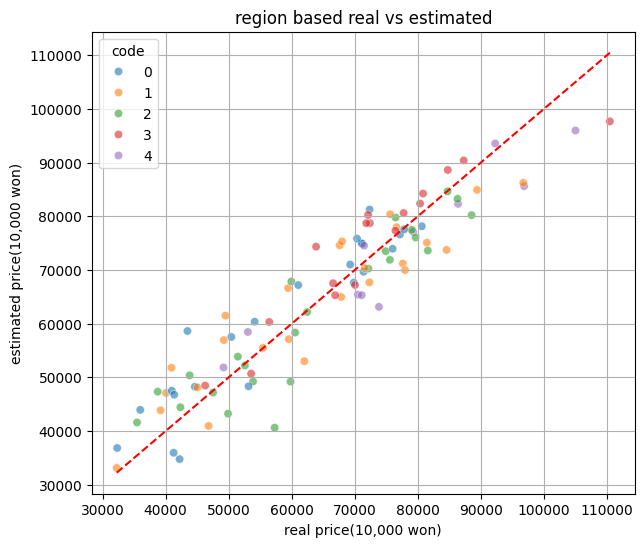

/Users/administrator/miniconda3/envs/multimodal_rag/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 13217 (\N{SQUARE M SQUARED}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


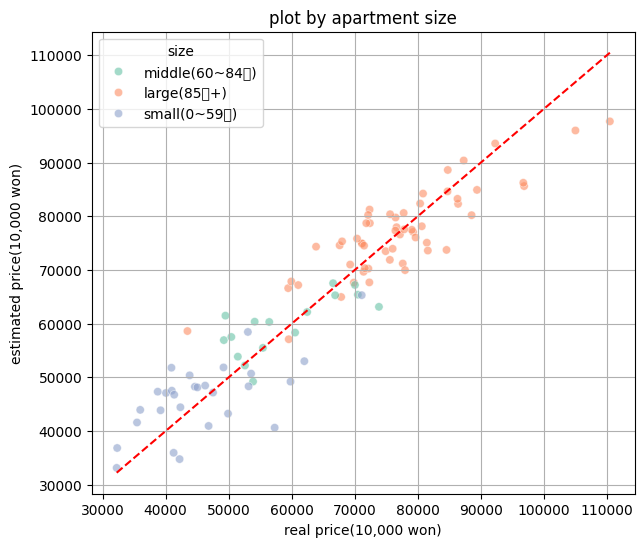

In [56]:
import seaborn as sns

# df_test : X_test index 기준으로 원본 데이터 위치 맞추기
df_test = df.loc[X_test.index]
df_test["code"] = df_test["지역코드"]
# (1) 지역 기반 색상
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=y_test,
    y=y_pred,
    hue=df_test["code"],
    palette="tab10",
    alpha=0.6
)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("region based real vs estimated")
plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.grid(True)
plt.show()


# (2) 평형대 만들기
def area_group(x):
    if x < 60:
        return "small(0~59㎡)"
    elif x <= 84:
        return "middle(60~84㎡)"
    else:
        return "large(85㎡+)"

df_test["size"] = df_test["전용면적"].apply(area_group)

# 평형대별 산점도
plt.figure(figsize=(7,6))
sns.scatterplot(
    x=y_test,
    y=y_pred,
    hue=df_test["size"],
    palette="Set2",
    alpha=0.6
)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.title("plot by apartment size")
plt.xlabel("real price(10,000 won)")
plt.ylabel("estimated price(10,000 won)")
plt.grid(True)
plt.show()
